# Resolución de la Ecuación de Calor 1D: MDF vs PINN

**Ecuaciones Diferenciales Parciales — Entrega 2**  
Emanuel Cabrera Novoa · Universidad de Medellín

---

Este notebook implementa y compara dos métodos de resolución para la ecuación de calor unidimensional:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

- **MDF**: Método de Diferencias Finitas, esquema explícito FTCS
- **PINN**: Red Neuronal Informada por la Física

Ambos se validan contra la solución analítica exacta:

$$u^*(x,t) = e^{-\alpha \pi^2 t} \sin\!\left(\frac{\pi x}{L}\right)$$

## 0. Importaciones

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Estilo de gráficas
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 120
})

## 1. Formulación del problema

Se considera la ecuación de calor unidimensional:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad (x,t) \in (0,L) \times (0,T)$$

Con condición inicial y condiciones de frontera (Dirichlet homogéneas):

$$u(x,0) = \sin\!\left(\frac{\pi x}{L}\right), \quad u(0,t) = 0, \quad u(L,t) = 0$$

El objetivo es aproximar $u(x,t)$ por dos vías:
1. Esquema FTCS (diferencias finitas explícitas)
2. Red neuronal $\hat{u}(x,t;\theta)$ entrenada para satisfacer la EDP (PINN)

## 2. Parámetros globales del problema

In [2]:
# --- Parámetros físicos ---
L     = 1.0   # Longitud de la barra (m)
T_max = 1.0   # Tiempo total de simulación (s)
alpha = 0.01  # Difusividad térmica (m²/s)

# --- Solución analítica exacta ---
def exacta(x, t):
    """
    u*(x,t) = exp(-alpha * pi^2 * t) * sin(pi * x / L)
    Obtenida por separación de variables. Modo n=1 es el único activo
    dado que la CI es exactamente sin(pi*x/L).
    """
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x / L)

print(f"Amplitud residual en t=T: exp(-alpha*pi^2*T) = {np.exp(-alpha*np.pi**2*T_max):.4f}")
print(f"  => la señal conserva el {np.exp(-alpha*np.pi**2*T_max)*100:.2f}% de su amplitud inicial")

Amplitud residual en t=T: exp(-alpha*pi^2*T) = 0.9060
  => la señal conserva el 90.60% de su amplitud inicial


---
## PARTE A — Método de Diferencias Finitas (FTCS)

### 3. Esquema explícito FTCS

El dominio se discretiza en una malla uniforme $(x_i, t^n)$. Las derivadas se aproximan:

$$\frac{\partial u}{\partial t} \approx \frac{u_i^{n+1} - u_i^n}{\Delta t}, \qquad
\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i-1}^n - 2u_i^n + u_{i+1}^n}{(\Delta x)^2}$$

Combinando, el esquema de avance es:

$$u_i^{n+1} = u_i^n + r\left(u_{i-1}^n - 2u_i^n + u_{i+1}^n\right), \quad r = \frac{\alpha \Delta t}{(\Delta x)^2}$$

**Condición de estabilidad de Von Neumann:** $r \leq 0.5$

In [3]:
# --- Parámetros de discretización MDF ---
Nx = 50                         # Nodos espaciales interiores
dx = L / Nx                     # Paso espacial
r  = 0.25                       # Número de Fourier (< 0.5 => estable)
dt = r * dx**2 / alpha          # Paso temporal derivado de r
Nt = int(T_max / dt)            # Número de pasos temporales

print(f"Δx = {dx:.4f} m  |  Δt = {dt:.6f} s  |  r = {r}  |  Nt = {Nt}")
print(f"Error de truncamiento: O(Δt) + O(Δx²) = O({dt:.1e}) + O({dx**2:.1e})")

x_mdf = np.linspace(0, L, Nx + 1)  # Incluye fronteras

# Condición inicial
u_mdf = np.sin(np.pi * x_mdf / L)

# Marcha temporal FTCS
for n in range(Nt):
    u_new = u_mdf.copy()
    u_new[1:-1] = u_mdf[1:-1] + r * (u_mdf[:-2] - 2*u_mdf[1:-1] + u_mdf[2:])
    u_new[0]  = 0.0   # Frontera izquierda
    u_new[-1] = 0.0   # Frontera derecha
    u_mdf = u_new

# Comparación con solución exacta en t = T_max
u_exact_mdf = exacta(x_mdf, T_max)
error_mdf_inf = np.max(np.abs(u_mdf - u_exact_mdf))
error_mdf_l2  = np.sqrt(np.mean((u_mdf - u_exact_mdf)**2))

print(f"\nResultados MDF en t = {T_max} s:")
print(f"  ||e||_inf = {error_mdf_inf:.2e}")
print(f"  ||e||_L2  = {error_mdf_l2:.2e}")

Δx = 0.0200 m  |  Δt = 0.010000 s  |  r = 0.25  |  Nt = 100
Error de truncamiento: O(Δt) + O(Δx²) = O(1.0e-02) + O(4.0e-04)

Resultados MDF en t = 1.0 s:
  ||e||_inf = 1.47e-05
  ||e||_L2  = 1.03e-05


---
## PARTE B — Red Neuronal Informada por la Física (PINN)

### 4. Residuo de la EDP

El residuo de la ecuación de calor se define como:

$$R(x,t) = \frac{\partial \hat{u}}{\partial t} - \alpha \frac{\partial^2 \hat{u}}{\partial x^2}$$

Las derivadas se calculan mediante **diferenciación automática** (autograd de PyTorch),
obteniendo gradientes exactos —sin error de truncamiento— a través del grafo computacional.

In [4]:
def pde_residual(model, x, t, alpha=0.01):
    """
    Calcula R(x,t) = ∂û/∂t - alpha * ∂²û/∂x²
    usando diferenciación automática en modo reverso.
    """
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)

    u = model(x, t)

    # ∂û/∂t
    u_t = torch.autograd.grad(
        u, t, torch.ones_like(u), create_graph=True
    )[0]

    # ∂û/∂x
    u_x = torch.autograd.grad(
        u, x, torch.ones_like(u), create_graph=True
    )[0]

    # ∂²û/∂x²
    u_xx = torch.autograd.grad(
        u_x, x, torch.ones_like(u_x), create_graph=True
    )[0]

    return u_t - alpha * u_xx

### 5. Construcción de los datos de entrenamiento

La PINN no usa datos experimentales. En su lugar, se construyen tres conjuntos de puntos donde se imponen restricciones físicas:

| Conjunto | Dónde | Qué se impone |
|----------|-------|---------------|
| IC ($N_{ic}$) | $t=0$, $x \in [0,L]$ | $\hat{u}(x,0) = \sin(\pi x/L)$ |
| BC ($N_{bc}$) | $x=0$ y $x=L$, $t \in [0,T]$ | $\hat{u}=0$ |
| PDE ($N_r$) | Interior del dominio, aleatorio | Residuo $R(x,t)=0$ |

In [5]:
N_ic  = 500
N_bc  = 500
N_pde = 10_000

# Condición inicial: t = 0, x uniforme en [0, L]
x_ic = torch.linspace(0, L, N_ic).view(-1, 1).float()
t_ic = torch.zeros(N_ic, 1).float()
u_ic = torch.sin(np.pi * x_ic / L).float()

# Condiciones de frontera: x = 0 y x = L
t_bc       = torch.linspace(0, T_max, N_bc // 2).view(-1, 1).float()
x_bc_left  = torch.zeros(N_bc // 2, 1).float()            # x = 0
x_bc_right = torch.full((N_bc // 2, 1), L).float()        # x = L
x_bc       = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc_total = torch.cat([t_bc, t_bc], dim=0)

# Puntos de colocación PDE: Monte Carlo en el interior
# x ~ U(0,L),  t ~ U(0,T)  — se evita la frontera intencionalmente
x_pde = torch.rand(N_pde, 1).float() * L
t_pde = torch.rand(N_pde, 1).float() * T_max

print(f"Puntos IC:  {N_ic}")
print(f"Puntos BC:  {N_bc}")
print(f"Puntos PDE: {N_pde}  (N_pde >> N_ic, N_bc para cubrir todo el dominio)")

Puntos IC:  500
Puntos BC:  500
Puntos PDE: 10000  (N_pde >> N_ic, N_bc para cubrir todo el dominio)


### 6. Arquitectura de la PINN

Se utiliza un perceptrón multicapa (MLP):

$$\mathbb{R}^2 \xrightarrow{\tanh} \mathbb{R}^{32} \xrightarrow{\tanh} \mathbb{R}^{32} \xrightarrow{\tanh} \mathbb{R}^{32} \xrightarrow{\text{id}} \mathbb{R}$$

**¿Por qué `tanh` y no `ReLU`?**  
La función `tanh` es $C^\infty$, lo que permite calcular $\partial^2 \hat{u}/\partial x^2$ mediante autograd.  
`ReLU` tiene segunda derivada nula casi en todas partes, imposibilitando imponer la EDP.

In [6]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),  nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = PINN()
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {n_params:,}")
print(model)

Parámetros totales: 2,241
PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 7. Función de pérdida compuesta

$$\mathcal{L}(\theta) = \mathcal{L}_{\text{PDE}} + \mathcal{L}_{\text{IC}} + \mathcal{L}_{\text{BC}}$$

$$\mathcal{L}_{\text{PDE}} = \frac{1}{N_r}\sum_k \left|\frac{\partial\hat{u}}{\partial t} - \alpha\frac{\partial^2\hat{u}}{\partial x^2}\right|^2_{(x_k,t_k)}$$

$$\mathcal{L}_{\text{IC}} = \frac{1}{N_{ic}}\sum_i \left|\hat{u}(x_i,0) - \sin\!\left(\frac{\pi x_i}{L}\right)\right|^2$$

$$\mathcal{L}_{\text{BC}} = \frac{1}{N_{bc}}\sum_j \left[|\hat{u}(0,t_j)|^2 + |\hat{u}(L,t_j)|^2\right]$$

In [7]:
# Historial de pérdida para graficar convergencia
history = {
    'total': [], 'pde': [], 'ic': [], 'bc': [], 'iter': []
}
iter_count = [0]

optimizer_adam  = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=50_000,
    tolerance_grad=1e-7,
    line_search_fn='strong_wolfe'
)

def closure():
    optimizer_adam.zero_grad()
    optimizer_lbfgs.zero_grad()

    loss_pde = torch.mean(pde_residual(model, x_pde, t_pde)**2)
    loss_ic  = torch.mean((model(x_ic, t_ic) - u_ic)**2)
    loss_bc  = torch.mean(model(x_bc, t_bc_total)**2)
    loss     = loss_pde + loss_ic + loss_bc

    loss.backward()

    # Guardar historial
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['bc'].append(loss_bc.item())
    history['iter'].append(iter_count[0])
    iter_count[0] += 1

    return loss

### 8. Estrategia de optimización: Adam + L-BFGS

**Fase 1 — Adam** (descenso por gradiente adaptativo): exploración rápida y robusta del espacio de parámetros. Evita mínimos locales desfavorables.  
**Fase 2 — L-BFGS** (cuasi-Newton de segundo orden): refinamiento fino hacia el mínimo con alta precisión matemática.

In [8]:
# --- Fase 1: Adam ---
print("Fase 1: Optimizando con Adam...")
n_adam = 2000
for i in range(n_adam):
    optimizer_adam.step(closure)
    if i % 500 == 0:
        print(f"  Iter {i:4d} | Loss total: {history['total'][-1]:.2e} "
              f"| PDE: {history['pde'][-1]:.2e} "
              f"| IC: {history['ic'][-1]:.2e} "
              f"| BC: {history['bc'][-1]:.2e}")

# Marcar frontera entre fases
iter_frontera = iter_count[0]

# --- Fase 2: L-BFGS ---
print("\nFase 2: Refinando con L-BFGS...")
optimizer_lbfgs.step(closure)
print(f"  Loss final: {history['total'][-1]:.2e} "
      f"| PDE: {history['pde'][-1]:.2e} "
      f"| IC: {history['ic'][-1]:.2e} "
      f"| BC: {history['bc'][-1]:.2e}")

Fase 1: Optimizando con Adam...
  Iter    0 | Loss total: 4.96e-01 | PDE: 3.22e-03 | IC: 4.92e-01 | BC: 8.07e-04
  Iter  500 | Loss total: 4.29e-04 | PDE: 3.48e-04 | IC: 4.10e-05 | BC: 4.02e-05
  Iter 1000 | Loss total: 7.33e-05 | PDE: 5.25e-05 | IC: 1.17e-05 | BC: 9.01e-06
  Iter 1500 | Loss total: 1.61e-05 | PDE: 1.20e-05 | IC: 2.24e-06 | BC: 1.90e-06

Fase 2: Refinando con L-BFGS...
  Loss final: 9.49e-07 | PDE: 6.95e-07 | IC: 4.19e-08 | BC: 2.12e-07


---
## PARTE C — Análisis de resultados

### 9. Curva de convergencia de la pérdida

Se grafican los tres términos de pérdida por separado en escala logarítmica,
permitiendo ver cuál restricción es más difícil de satisfacer y cómo cambia la dinámica entre las dos fases de optimización.

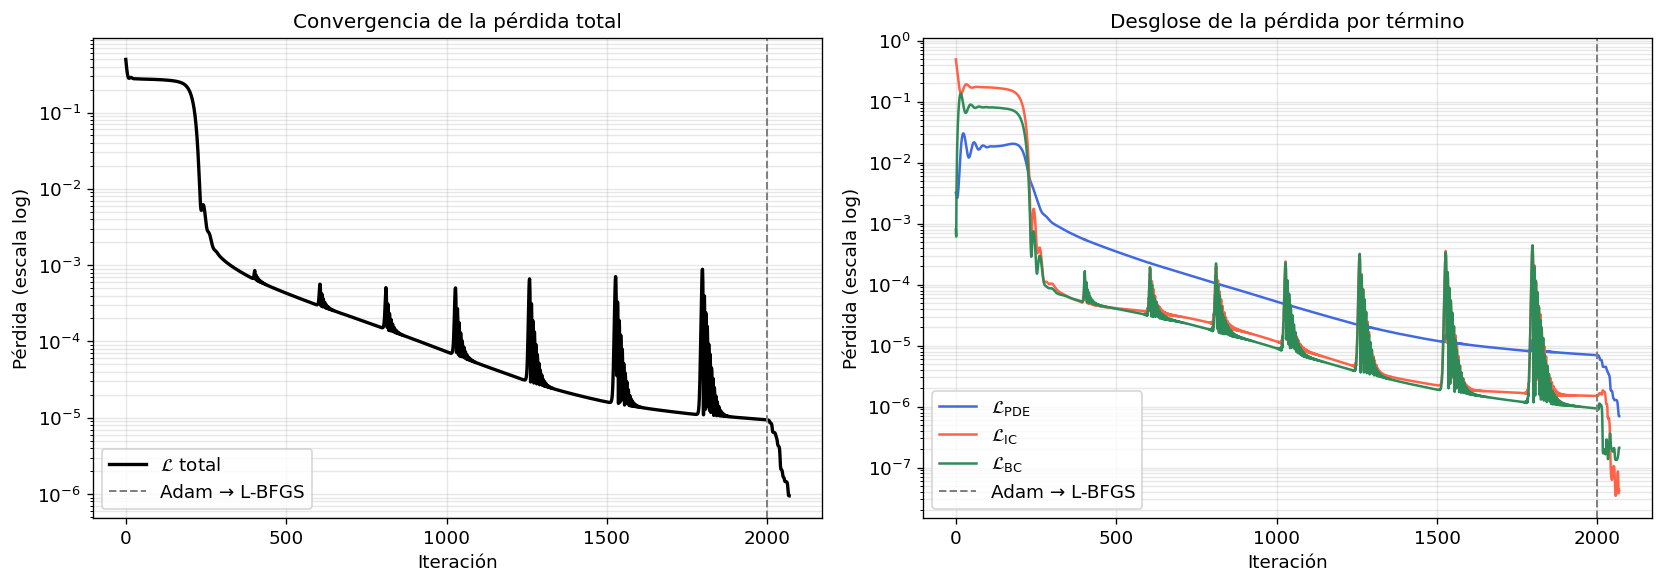

Figura guardada: fig_convergencia.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = history['iter']

# --- Izquierda: pérdida total ---
ax = axes[0]
ax.semilogy(iters, history['total'], color='black', lw=2, label='$\\mathcal{L}$ total')
ax.axvline(iter_frontera, color='gray', ls='--', lw=1.2, label='Adam → L-BFGS')
ax.set_xlabel('Iteración')
ax.set_ylabel('Pérdida (escala log)')
ax.set_title('Convergencia de la pérdida total')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# --- Derecha: desglose por término ---
ax = axes[1]
ax.semilogy(iters, history['pde'], label='$\\mathcal{L}_{\\mathrm{PDE}}$', color='royalblue')
ax.semilogy(iters, history['ic'],  label='$\\mathcal{L}_{\\mathrm{IC}}$',  color='tomato')
ax.semilogy(iters, history['bc'],  label='$\\mathcal{L}_{\\mathrm{BC}}$',  color='seagreen')
ax.axvline(iter_frontera, color='gray', ls='--', lw=1.2, label='Adam → L-BFGS')
ax.set_xlabel('Iteración')
ax.set_ylabel('Pérdida (escala log)')
ax.set_title('Desglose de la pérdida por término')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_convergencia.pdf', bbox_inches='tight')
plt.show()
print("Figura guardada: fig_convergencia.pdf")

### 10. Errores de la PINN por norma

In [10]:
x_test = torch.linspace(0, L, 200).view(-1, 1).float()

tiempos_eval = [0.0, 0.2, 0.5, 1.0]

print(f"{'t (s)':>6} | {'||e||_inf (PINN)':>18} | {'||e||_L2 (PINN)':>16}")
print("-" * 48)

errors_pinn_inf = []
errors_pinn_l2  = []

for t_val in tiempos_eval:
    t_test = torch.full_like(x_test, t_val)
    with torch.no_grad():
        u_pred = model(x_test, t_test).numpy().flatten()
    u_true = exacta(x_test.numpy().flatten(), t_val)

    e_inf = np.max(np.abs(u_pred - u_true))
    e_l2  = np.sqrt(np.mean((u_pred - u_true)**2))
    errors_pinn_inf.append(e_inf)
    errors_pinn_l2.append(e_l2)

    print(f"{t_val:>6.1f} | {e_inf:>18.2e} | {e_l2:>16.2e}")

 t (s) |   ||e||_inf (PINN) |  ||e||_L2 (PINN)
------------------------------------------------
   0.0 |           9.30e-04 |         2.09e-04
   0.2 |           5.95e-04 |         2.32e-04
   0.5 |           4.20e-04 |         1.97e-04
   1.0 |           1.08e-03 |         1.97e-04


### 11. Tabla comparativa de errores: MDF vs PINN en múltiples instantes

In [11]:
# Recalcular MDF guardando snapshots en los instantes de interés
x_mdf_full = np.linspace(0, L, Nx + 1)
u_snap = {}  # {t_val: u_array}

u_cur = np.sin(np.pi * x_mdf_full / L)
t_cur = 0.0
u_snap[0.0] = u_cur.copy()

for n in range(Nt):
    u_new = u_cur.copy()
    u_new[1:-1] = u_cur[1:-1] + r * (u_cur[:-2] - 2*u_cur[1:-1] + u_cur[2:])
    u_new[0] = 0.0
    u_new[-1] = 0.0
    u_cur = u_new
    t_cur += dt
    for t_snap in [0.2, 0.5, 1.0]:
        if abs(t_cur - t_snap) < dt / 2 and t_snap not in u_snap:
            u_snap[t_snap] = u_cur.copy()

print(f"{'t (s)':>6} | {'||e||_inf MDF':>14} | {'||e||_L2 MDF':>13} | {'||e||_inf PINN':>15} | {'||e||_L2 PINN':>14}")
print("-" * 72)

for i, t_val in enumerate(tiempos_eval):
    u_m  = u_snap.get(t_val, np.zeros_like(x_mdf_full))
    u_ex = exacta(x_mdf_full, t_val)
    e_m_inf = np.max(np.abs(u_m - u_ex))
    e_m_l2  = np.sqrt(np.mean((u_m - u_ex)**2))
    print(f"{t_val:>6.1f} | {e_m_inf:>14.2e} | {e_m_l2:>13.2e} | "
          f"{errors_pinn_inf[i]:>15.2e} | {errors_pinn_l2[i]:>14.2e}")

 t (s) |  ||e||_inf MDF |  ||e||_L2 MDF |  ||e||_inf PINN |  ||e||_L2 PINN
------------------------------------------------------------------------
   0.0 |       0.00e+00 |      0.00e+00 |        9.30e-04 |       2.09e-04
   0.2 |       3.18e-06 |      2.23e-06 |        5.95e-04 |       2.32e-04
   0.5 |       7.73e-06 |      5.41e-06 |        4.20e-04 |       1.97e-04
   1.0 |       1.47e-05 |      1.03e-05 |        1.08e-03 |       1.97e-04


### 12. Comparativa visual: Analítica vs MDF vs PINN

Esta es la figura central del proyecto: las tres soluciones superpuestas en perfiles temporales y mapas de calor.

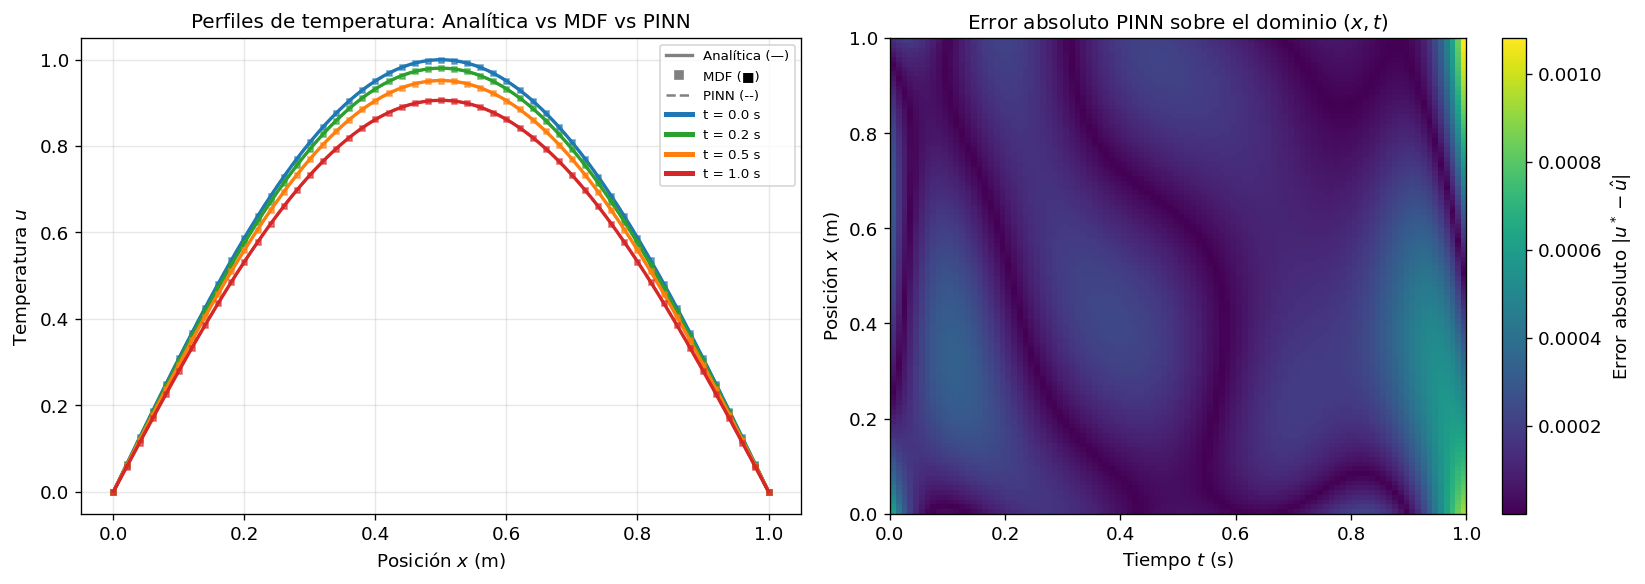

Figura guardada: fig_comparativa.pdf


In [12]:
x_plot = np.linspace(0, L, 200)
colors  = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Izquierda: perfiles en t fijo ---
ax = axes[0]
for idx, t_val in enumerate(tiempos_eval):
    c = colors[idx]

    # Analítica
    u_an = exacta(x_plot, t_val)
    ax.plot(x_plot, u_an, '-', color=c, lw=2,
            label=f'Analítica t={t_val}' if idx == 0 else f't={t_val}')

    # MDF (interpolado a x_plot)
    u_m = u_snap.get(t_val, np.zeros_like(x_mdf_full))
    ax.plot(x_mdf_full, u_m, 's', color=c, ms=3, alpha=0.6,
            label='MDF' if idx == 0 else '')

    # PINN
    x_t = torch.tensor(x_plot, dtype=torch.float32).view(-1, 1)
    t_t = torch.full_like(x_t, t_val)
    with torch.no_grad():
        u_p = model(x_t, t_t).numpy().flatten()
    ax.plot(x_plot, u_p, '--', color=c, lw=1.5,
            label='PINN' if idx == 0 else '')

ax.set_xlabel('Posición $x$ (m)')
ax.set_ylabel('Temperatura $u$')
ax.set_title('Perfiles de temperatura: Analítica vs MDF vs PINN')
ax.grid(True, alpha=0.3)

# Leyenda simplificada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='gray', lw=2,  label='Analítica (—)'),
    Line2D([0],[0], color='gray', lw=0, marker='s', ms=5, label='MDF (■)'),
    Line2D([0],[0], color='gray', lw=1.5, ls='--', label='PINN (--)')
]
for idx, t_val in enumerate(tiempos_eval):
    legend_elements.append(
        Line2D([0],[0], color=colors[idx], lw=3, label=f't = {t_val} s')
    )
ax.legend(handles=legend_elements, fontsize=8, loc='upper right')

# --- Derecha: mapa de calor del error absoluto PINN - Analítica ---
ax = axes[1]
x_g = np.linspace(0, L, 100)
t_g = np.linspace(0, T_max, 100)
X_g, T_g = np.meshgrid(x_g, t_g)

x_f = torch.tensor(X_g.flatten(), dtype=torch.float32).view(-1,1)
t_f = torch.tensor(T_g.flatten(), dtype=torch.float32).view(-1,1)
with torch.no_grad():
    u_pinn_grid = model(x_f, t_f).numpy().reshape(100, 100)

u_exact_grid = exacta(X_g, T_g)
error_grid   = np.abs(u_exact_grid - u_pinn_grid)

im = ax.imshow(error_grid, extent=[0, T_max, 0, L],
               origin='lower', aspect='auto', cmap='viridis')
fig.colorbar(im, ax=ax, label='Error absoluto $|u^* - \\hat{u}|$')
ax.set_xlabel('Tiempo $t$ (s)')
ax.set_ylabel('Posición $x$ (m)')
ax.set_title('Error absoluto PINN sobre el dominio $(x,t)$')

plt.tight_layout()
plt.savefig('fig_comparativa.pdf', bbox_inches='tight')
plt.show()
print("Figura guardada: fig_comparativa.pdf")

### 13. Mapas de calor completos: Analítica, MDF y PINN

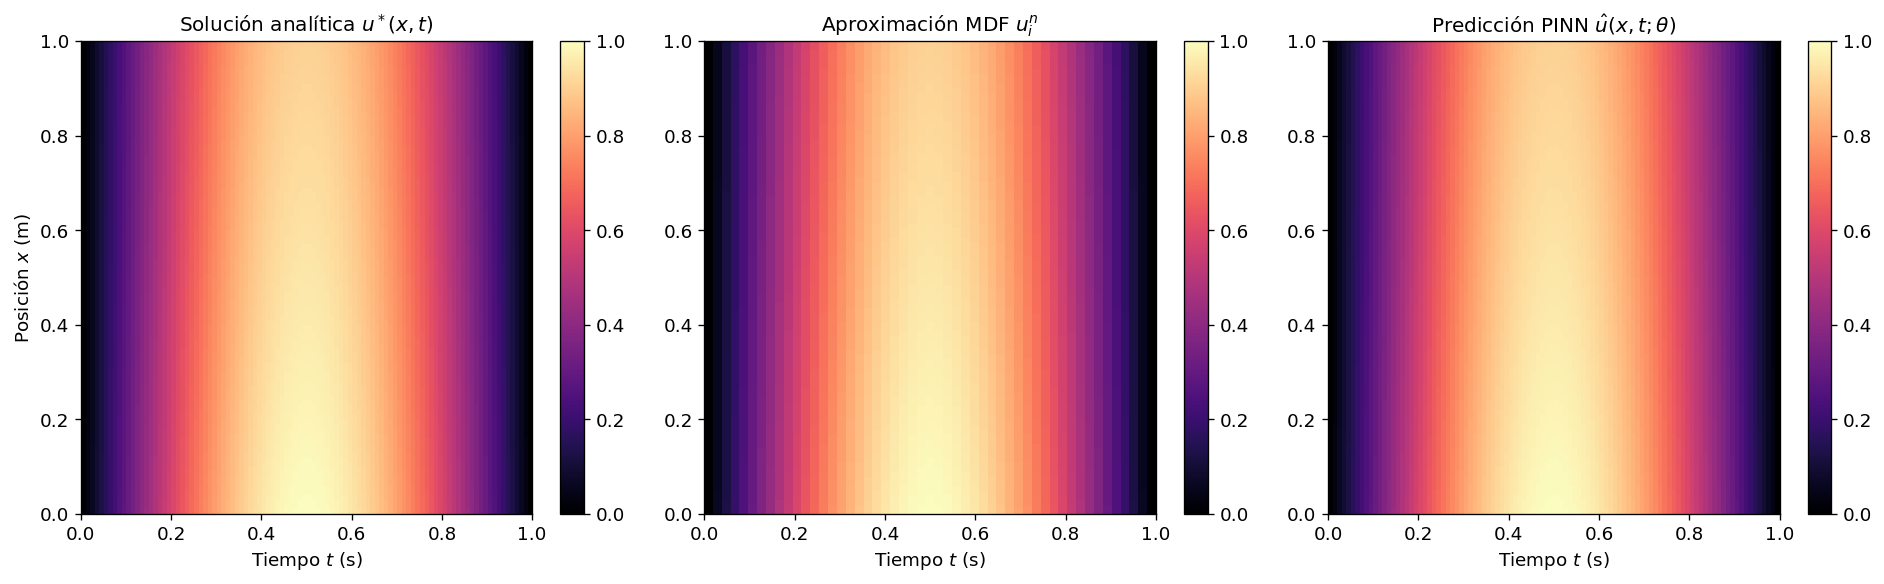

Figura guardada: fig_mapas_calor.pdf


In [13]:
# Reconstruir solución MDF en toda la malla espacio-temporal
u_mdf_full = np.zeros((Nt + 1, Nx + 1))
u_mdf_full[0] = np.sin(np.pi * x_mdf_full / L)
for n in range(Nt):
    u_mdf_full[n+1, 1:-1] = (u_mdf_full[n, 1:-1]
                              + r * (u_mdf_full[n, :-2]
                                     - 2*u_mdf_full[n, 1:-1]
                                     + u_mdf_full[n, 2:]))

t_mdf_full = np.linspace(0, T_max, Nt + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmap = 'magma'
vmin, vmax = 0, 1

# Analítica
im0 = axes[0].imshow(u_exact_grid, extent=[0, T_max, 0, L],
                     origin='lower', aspect='auto', cmap=cmap,
                     vmin=vmin, vmax=vmax)
axes[0].set_title('Solución analítica $u^*(x,t)$')
axes[0].set_xlabel('Tiempo $t$ (s)')
axes[0].set_ylabel('Posición $x$ (m)')
fig.colorbar(im0, ax=axes[0])

# MDF (submuestreado)
u_mdf_plot = u_mdf_full[::max(1, Nt//100), :]
im1 = axes[1].imshow(u_mdf_plot, extent=[0, T_max, 0, L],
                     origin='lower', aspect='auto', cmap=cmap,
                     vmin=vmin, vmax=vmax)
axes[1].set_title('Aproximación MDF $u_i^n$')
axes[1].set_xlabel('Tiempo $t$ (s)')
fig.colorbar(im1, ax=axes[1])

# PINN
im2 = axes[2].imshow(u_pinn_grid, extent=[0, T_max, 0, L],
                     origin='lower', aspect='auto', cmap=cmap,
                     vmin=vmin, vmax=vmax)
axes[2].set_title('Predicción PINN $\\hat{u}(x,t;\\theta)$')
axes[2].set_xlabel('Tiempo $t$ (s)')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('fig_mapas_calor.pdf', bbox_inches='tight')
plt.show()
print("Figura guardada: fig_mapas_calor.pdf")

### 14. Resumen final de resultados

In [14]:
print("=" * 60)
print("RESUMEN DE RESULTADOS")
print("=" * 60)

print(f"\n[MDF — FTCS]")
print(f"  Δx = {dx:.4f} m  |  Δt = {dt:.6f} s  |  r = {r}")
print(f"  Nodos: {Nx+1} espaciales × {Nt+1} temporales")
print(f"  Error en t = {T_max} s:")
u_ex_final = exacta(x_mdf_full, T_max)
print(f"    ||e||_inf = {np.max(np.abs(u_mdf_full[-1] - u_ex_final)):.2e}")
print(f"    ||e||_L2  = {np.sqrt(np.mean((u_mdf_full[-1] - u_ex_final)**2)):.2e}")

print(f"\n[PINN — MLP 2→32→32→32→1, tanh]")
print(f"  Parámetros: {n_params:,}")
print(f"  Iteraciones Adam: 2000  |  L-BFGS: hasta tolerancia 1e-7")
print(f"  Pérdida final: {history['total'][-1]:.2e}")
print(f"    PDE: {history['pde'][-1]:.2e}  "
      f"IC: {history['ic'][-1]:.2e}  "
      f"BC: {history['bc'][-1]:.2e}")
print(f"  Error en t = {T_max} s:")
print(f"    ||e||_inf = {errors_pinn_inf[-1]:.2e}")
print(f"    ||e||_L2  = {errors_pinn_l2[-1]:.2e}")
print("=" * 60)

RESUMEN DE RESULTADOS

[MDF — FTCS]
  Δx = 0.0200 m  |  Δt = 0.010000 s  |  r = 0.25
  Nodos: 51 espaciales × 101 temporales
  Error en t = 1.0 s:
    ||e||_inf = 1.47e-05
    ||e||_L2  = 1.03e-05

[PINN — MLP 2→32→32→32→1, tanh]
  Parámetros: 2,241
  Iteraciones Adam: 2000  |  L-BFGS: hasta tolerancia 1e-7
  Pérdida final: 9.49e-07
    PDE: 6.95e-07  IC: 4.19e-08  BC: 2.12e-07
  Error en t = 1.0 s:
    ||e||_inf = 1.08e-03
    ||e||_L2  = 1.97e-04
